In [30]:
import os
import io
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ROUND 1

In [2]:
zip_file_path = '../data/logs/round_1/272312.zip'

In [3]:
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

In [4]:
data_json.keys()

dict_keys(['round', 'status', 'profit', 'activitiesLog', 'graphLog', 'positions'])

In [5]:
data_log.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [6]:
activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

In [7]:
price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

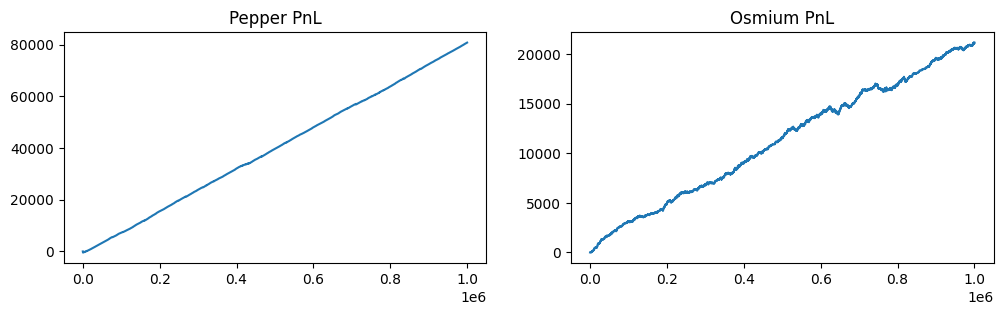

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(price_pepper['profit_and_loss'])
ax[0].set_title('Pepper PnL')
ax[1].plot(price_osmium['profit_and_loss'])
ax[1].set_title('Osmium PnL')
plt.show()

In [9]:
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Pepper Min PnL: {price_pepper['profit_and_loss'].min()}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Osmium Min PnL: {price_osmium['profit_and_loss'].min()}')

Pepper Final PnL: 80769.25
Pepper Min PnL: -456.5
Osmium Final PnL: 21144.9375
Osmium Min PnL: -11.88671875


In [10]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

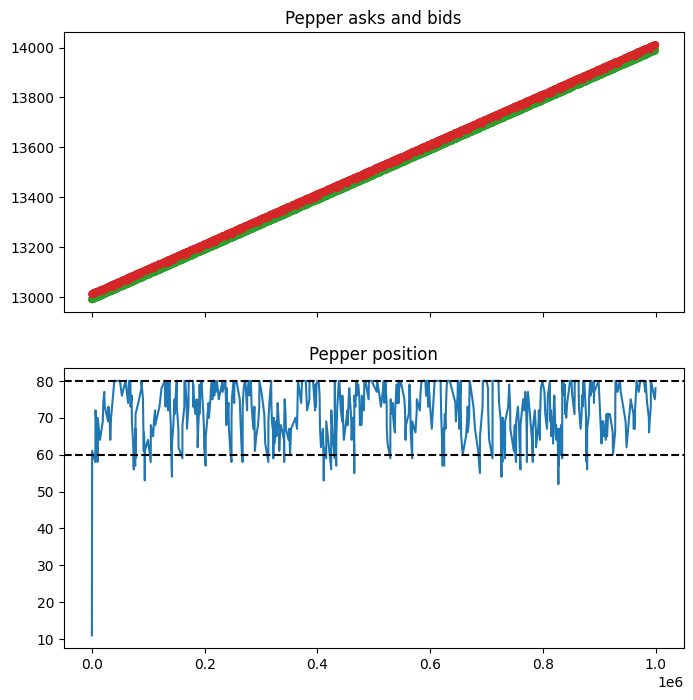

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_pepper.index, price_pepper['bid_price_1'], s=price_pepper['bid_volume_1'], c='tab:green')
ax[0].scatter(price_pepper.index, price_pepper['ask_price_1'], s=price_pepper['ask_volume_1'], c='tab:red')
ax[0].set_title('Pepper asks and bids')
ax[1].plot(trades_pepper['position'])
ax[1].set_title('Pepper position')
ax[1].axhline(60, c='k', linestyle='dashed')
ax[1].axhline(80, c='k', linestyle='dashed')
plt.show()

In [12]:
edge_to_mean = 10000 - price_osmium['ask_price_1']  # Profit expected when reverting up to mean
half_spread = price_osmium['ask_price_1'] - price_osmium['mid_price']  # Cost paid to cross the spread
snap_back_buys = edge_to_mean > (half_spread + 1)

edge_to_mean = price_osmium['bid_price_1'] - 10000  # Profit expected when crashing down to mean
half_spread = price_osmium['mid_price'] - price_osmium['bid_price_1']  # Cost paid to cross the spread
snap_back_sells = edge_to_mean > (half_spread + 1)

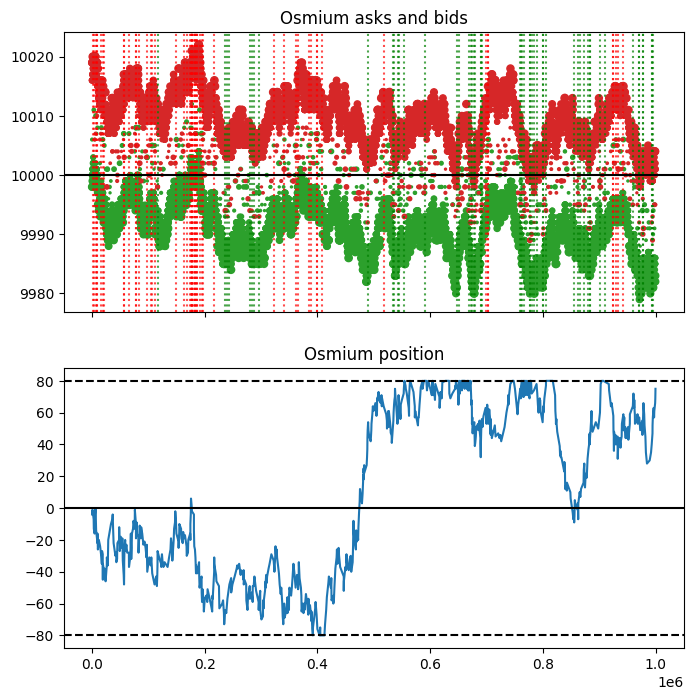

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_osmium.index, price_osmium['bid_price_1'], s=price_osmium['bid_volume_1'], c='tab:green')
ax[0].scatter(price_osmium.index, price_osmium['ask_price_1'], s=price_osmium['ask_volume_1'], c='tab:red')
ax[0].axhline(10000, c='k')
for x in snap_back_buys[snap_back_buys].index:
    ax[0].axvline(x=x, color='green', linestyle='dotted', alpha=0.7)
for x in snap_back_sells[snap_back_sells].index:
    ax[0].axvline(x=x, color='red', linestyle='dotted', alpha=0.7)
ax[0].set_title('Osmium asks and bids')
ax[1].plot(trades_osmium['position'])
ax[1].axhline(0, c='k')
ax[1].axhline(80, c='k', linestyle='dashed')
ax[1].axhline(-80, c='k', linestyle='dashed')
ax[1].set_title('Osmium position')
plt.show()

# ROUND 2

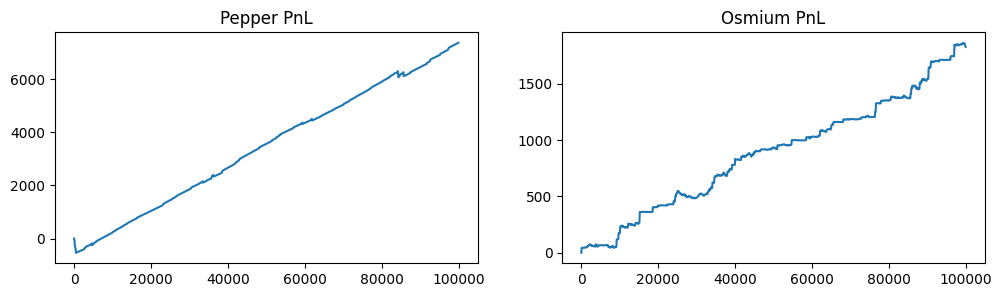

In [14]:
zip_file_path = '../data/logs/round_2/291877.zip'
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(price_pepper['profit_and_loss'])
ax[0].set_title('Pepper PnL')
ax[1].plot(price_osmium['profit_and_loss'])
ax[1].set_title('Osmium PnL')
plt.show()

In [15]:
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Pepper Min PnL: {price_pepper['profit_and_loss'].min()}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Osmium Min PnL: {price_osmium['profit_and_loss'].min()}')

Pepper Final PnL: 7364.5
Pepper Min PnL: -535.5
Osmium Final PnL: 1824.796875
Osmium Min PnL: 0.0


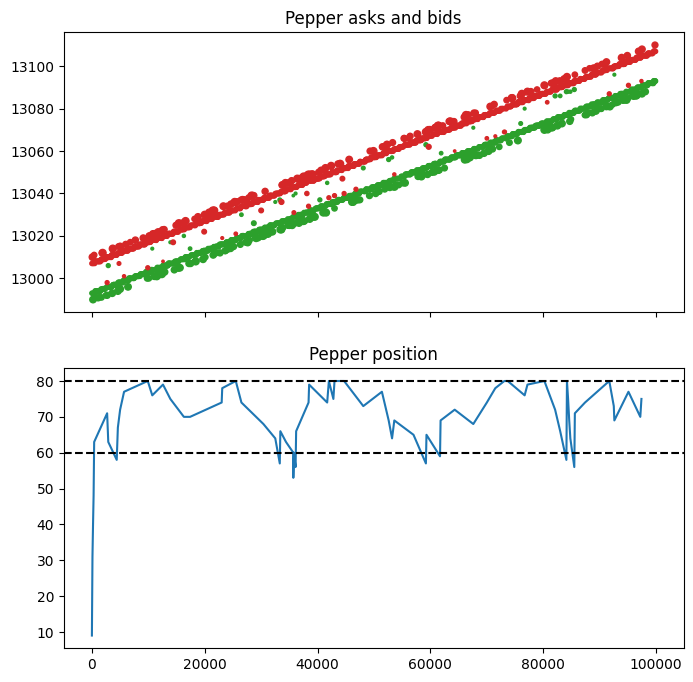

In [16]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_pepper.index, price_pepper['bid_price_1'], s=price_pepper['bid_volume_1'], c='tab:green')
ax[0].scatter(price_pepper.index, price_pepper['ask_price_1'], s=price_pepper['ask_volume_1'], c='tab:red')
ax[0].set_title('Pepper asks and bids')
ax[1].plot(trades_pepper['position'])
ax[1].set_title('Pepper position')
ax[1].axhline(60, c='k', linestyle='dashed')
ax[1].axhline(80, c='k', linestyle='dashed')
plt.show()

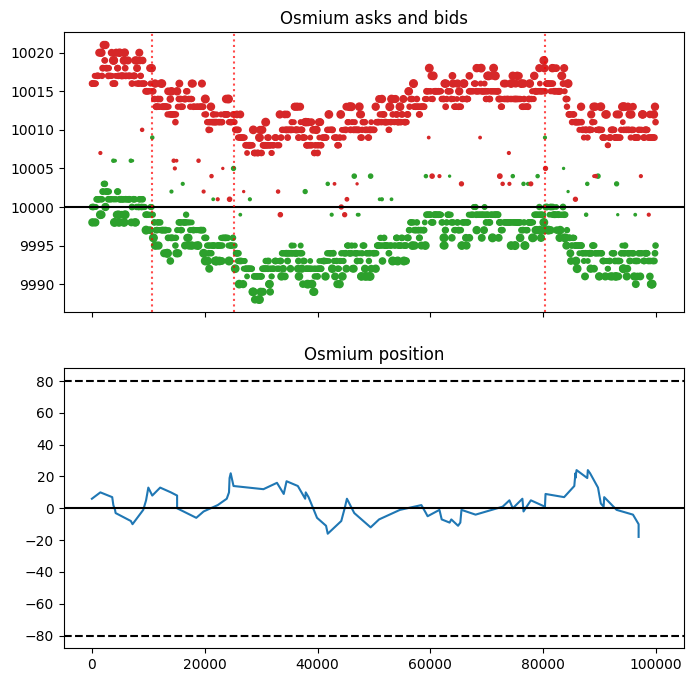

In [17]:
edge_to_mean = 10000 - price_osmium['ask_price_1']  # Profit expected when reverting up to mean
half_spread = price_osmium['ask_price_1'] - price_osmium['mid_price']  # Cost paid to cross the spread
snap_back_buys = edge_to_mean > (half_spread + 1)

edge_to_mean = price_osmium['bid_price_1'] - 10000  # Profit expected when crashing down to mean
half_spread = price_osmium['mid_price'] - price_osmium['bid_price_1']  # Cost paid to cross the spread
snap_back_sells = edge_to_mean > (half_spread + 1)

fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_osmium.index, price_osmium['bid_price_1'], s=price_osmium['bid_volume_1'], c='tab:green')
ax[0].scatter(price_osmium.index, price_osmium['ask_price_1'], s=price_osmium['ask_volume_1'], c='tab:red')
ax[0].axhline(10000, c='k')
for x in snap_back_buys[snap_back_buys].index:
    ax[0].axvline(x=x, color='green', linestyle='dotted', alpha=0.7)
for x in snap_back_sells[snap_back_sells].index:
    ax[0].axvline(x=x, color='red', linestyle='dotted', alpha=0.7)
ax[0].set_title('Osmium asks and bids')
ax[1].plot(trades_osmium['position'])
ax[1].axhline(0, c='k')
ax[1].axhline(80, c='k', linestyle='dashed')
ax[1].axhline(-80, c='k', linestyle='dashed')
ax[1].set_title('Osmium position')
plt.show()